Importo los datos y los organizo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
import json

In [2]:
# Cargar el archivo CSV para análisis
file_path = 'parametros_ajuste_nelder.csv'
df = pd.read_csv(file_path)

# Convertir la columna 'File_Name' a datetime (asumiendo que es una columna)
df['timestamp'] = pd.to_datetime(df['File_Name'], format='%Y-%m-%d_%H:%M:%S')

# Extraer la hora del día de la estampa de tiempo
df['hora_del_dia'] = df['timestamp'].dt.time

df['ID'] = range(1, len(df) + 1)

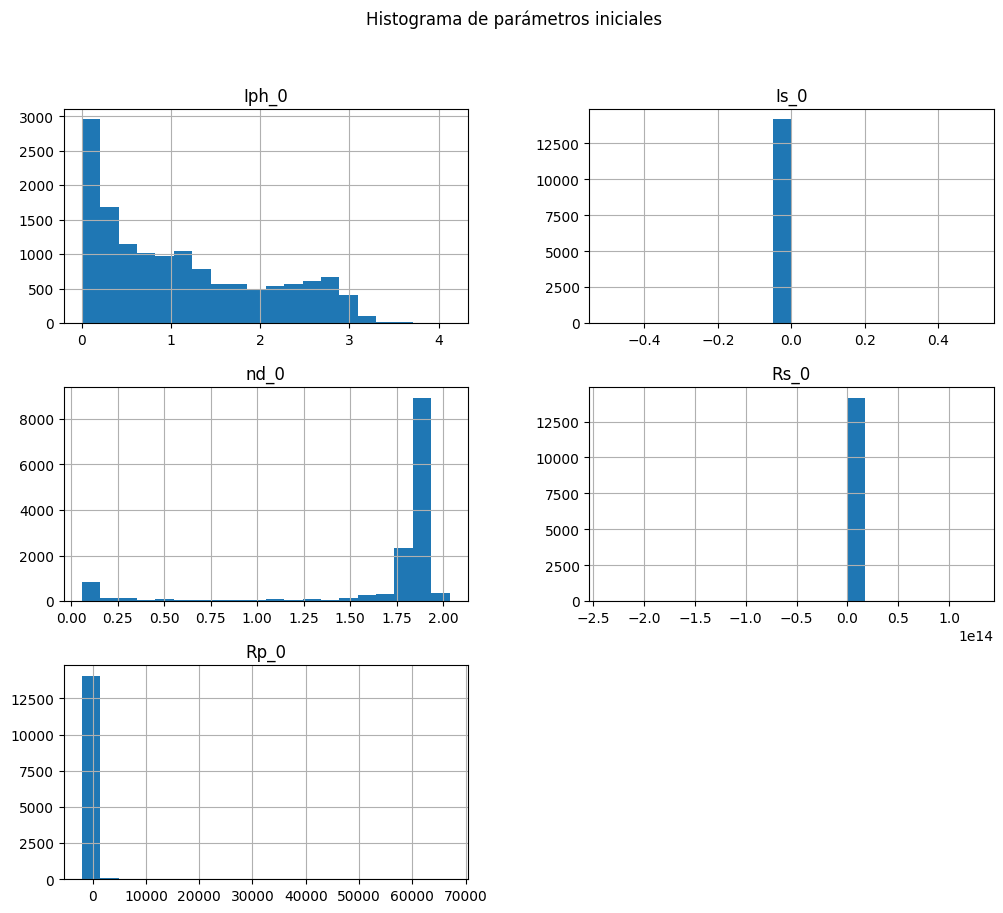

In [4]:
# Histogramas de los parámetros iniciales y ajustados
parametros_iniciales = ['Iph_0', 'Is_0','nd_0', 'Rs_0', 'Rp_0']
df[parametros_iniciales].hist(bins=20, figsize=(12, 10))
plt.suptitle('Histograma de parámetros iniciales')
plt.show()

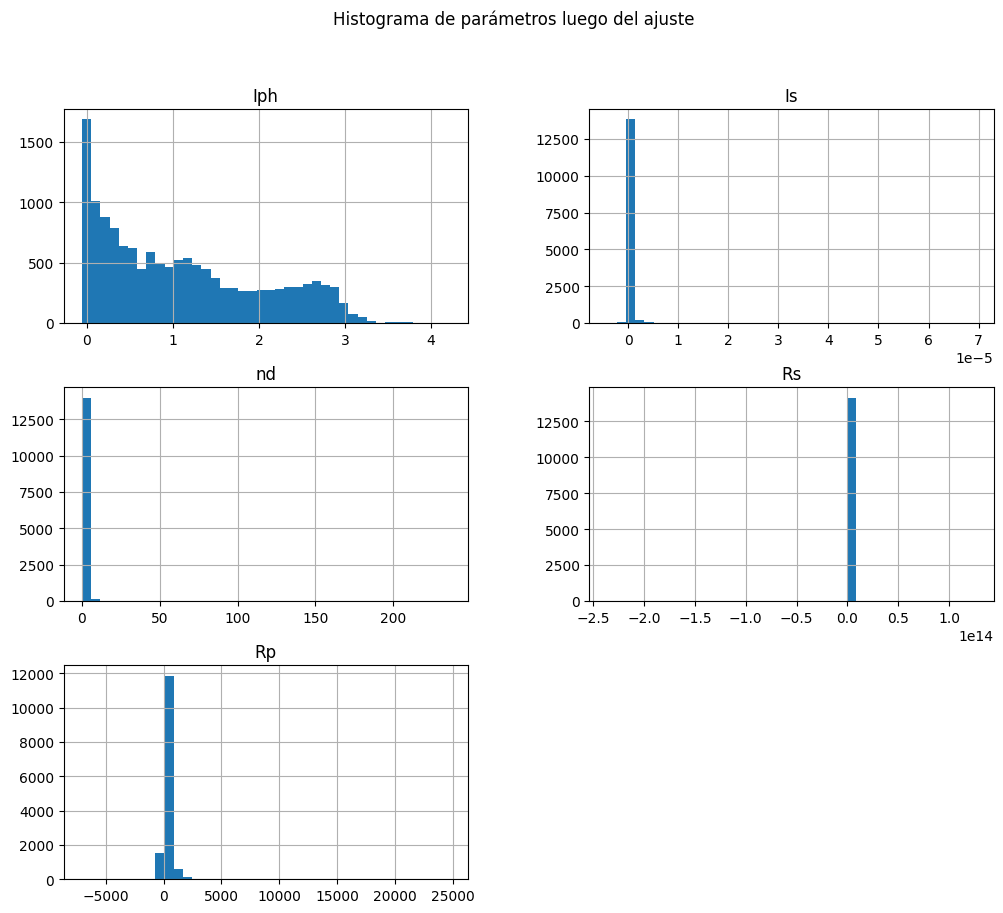

In [5]:
# Histogramas de los parámetros luego del ajuste
parametros_iniciales = ['Iph','Is', 'nd', 'Rs', 'Rp']
df[parametros_iniciales].hist(bins=40, figsize=(12, 10))
plt.suptitle('Histograma de parámetros luego del ajuste')
plt.show()

**¿Cómo se comporta el Coeficiente de Pearson?**

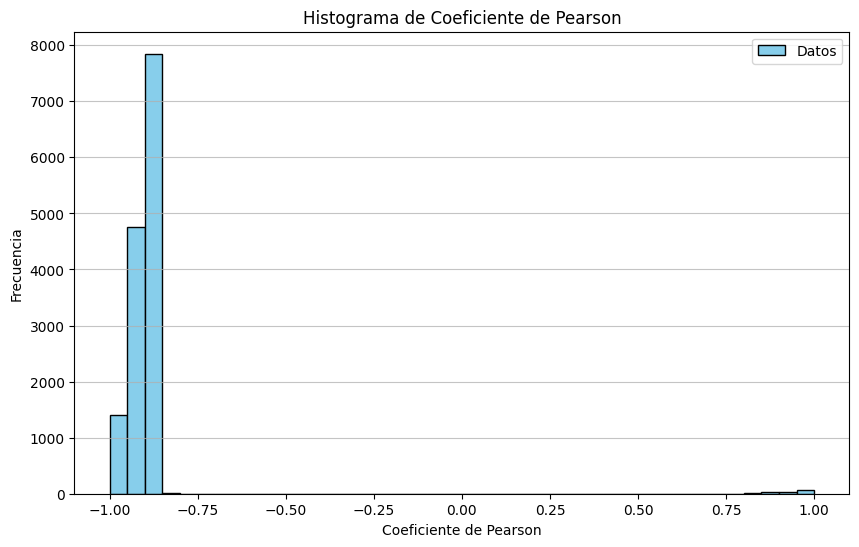

In [46]:
# Histograma del Coeficiente de Pearson
plt.figure(figsize=(10, 6))
plt.hist(df['Coef_Pearson'], bins=40, color='skyblue', edgecolor='black', label='Datos')
plt.title('Histograma de Coeficiente de Pearson')
plt.xlabel('Coeficiente de Pearson')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend()  
plt.show()


**Filtro 1**
Se descartan curvas con Coeficiente de Pearson >= -0.2 o de tipo NaN


In [47]:
# Filtrar coeficientes de Pearson mayores o iguales a -0.2 o donde son NaN
filtro1 = df[(df['Coef_Pearson'] >= -0.2) | (df['Coef_Pearson'].isna())]
count1 = filtro1.shape[0]
print("Número de curvas filtradas con Coeficiente de Pearson >= -0.2 o tipo NaN:", count1)

Número de curvas filtradas con Coeficiente de Pearson >= -0.2 o tipo NaN: 155


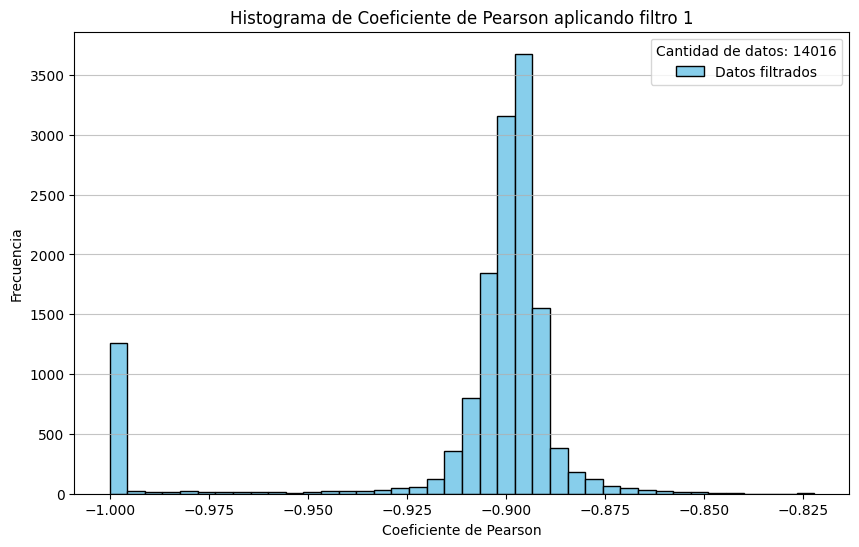

In [48]:
# Filtrar coeficientes de Pearson menores a -0.2
df_filtered = df[df['Coef_Pearson'] < -0.2]

# Contar la cantidad de datos filtrados
count = df_filtered.shape[0]

# Crear el histograma
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['Coef_Pearson'], bins=40, color='skyblue', edgecolor='black', label='Datos filtrados')
plt.title('Histograma de Coeficiente de Pearson aplicando filtro 1')
plt.xlabel('Coeficiente de Pearson')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend(title=f'Cantidad de datos: {count}')  # Agregar la leyenda aquí
plt.show()


**Filtro 2**
Se descartan curvas con Coeficiente de Pearson <= -0.94 o de tipo NaN

In [49]:
# Filtrar coeficientes de Pearson menores o iguales a -0.94 o donde son NaN
filtro2 = df[(df['Coef_Pearson'] <= -0.945)]
count2 = filtro2.shape[0]
print("Número de curvas filtradas con Coeficiente de Pearson <= -0.95:", count2)

Número de curvas filtradas con Coeficiente de Pearson <= -0.95: 1413


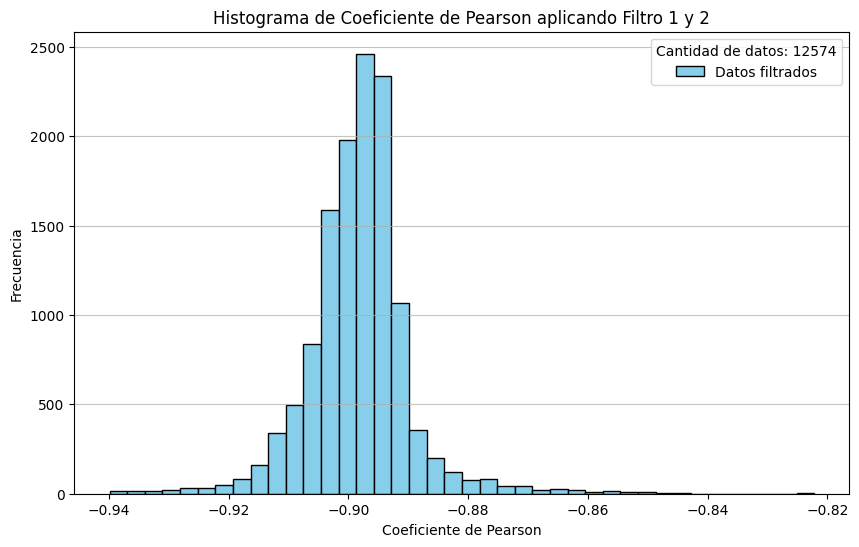

In [50]:
df_filtered = df[(df['Coef_Pearson'] > -0.94) & (df['Coef_Pearson'] < -0.2)]

# Contar la cantidad de datos filtrados
count = df_filtered.shape[0]

# Crear el histograma
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['Coef_Pearson'], bins=40, color='skyblue', edgecolor='black', label='Datos filtrados')
plt.title('Histograma de Coeficiente de Pearson aplicando Filtro 1 y 2')
plt.xlabel('Coeficiente de Pearson')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend(title=f'Cantidad de datos: {count}')  # Agregar la leyenda aquí
plt.show()

**¿Cómo se comporta el factor de idealidad del diodo (nd) ?**

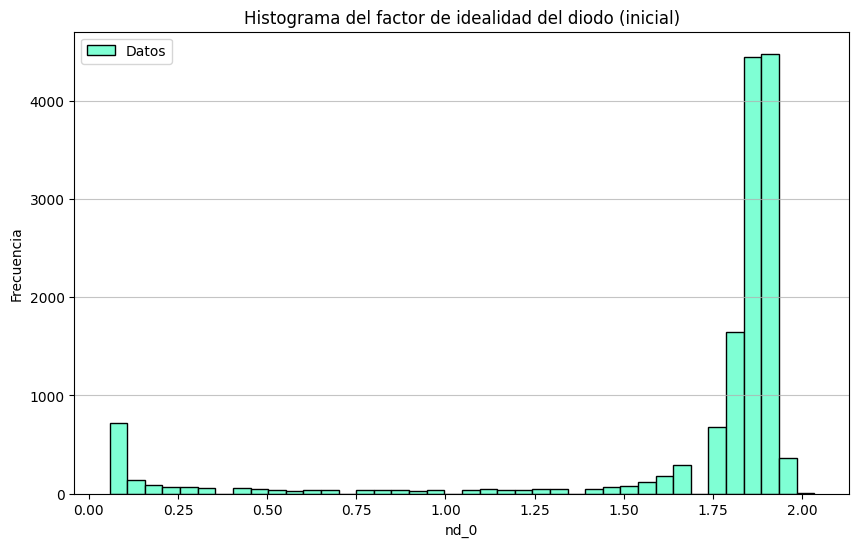

In [51]:
# Histograma del Factor de Idealidad del diodo (inicial)
plt.figure(figsize=(10, 6))
plt.hist(df['nd_0'], bins=40, color='aquamarine', edgecolor='black', label='Datos')
plt.title('Histograma del factor de idealidad del diodo (inicial)')
plt.xlabel('nd_0')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend()  
plt.show()

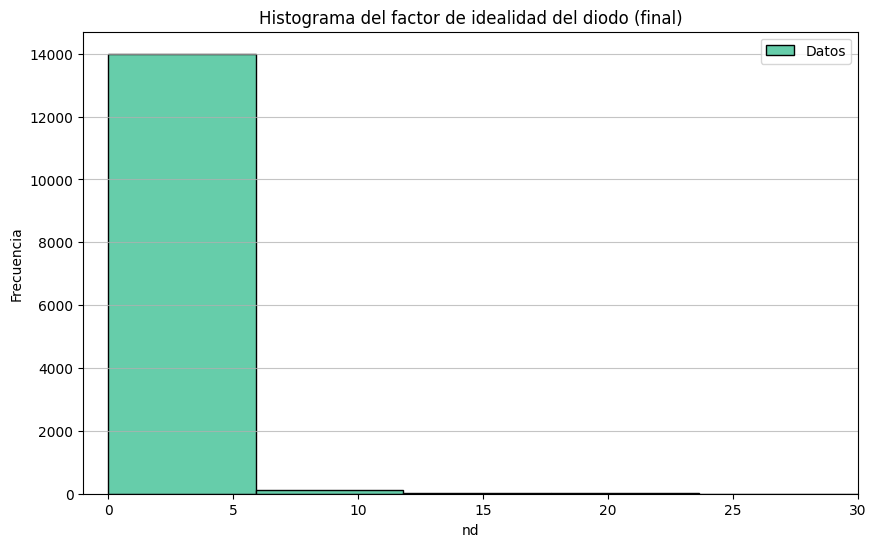

In [5]:
# Histograma del Factor de Idealidad del diodo (final)
plt.figure(figsize=(10, 6))
plt.hist(df['nd'], bins=40, color='mediumaquamarine', edgecolor='black', label='Datos')
plt.title('Histograma del factor de idealidad del diodo (final)')
plt.xlabel('nd')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.xlim(-1,30)
plt.legend()  
plt.show()

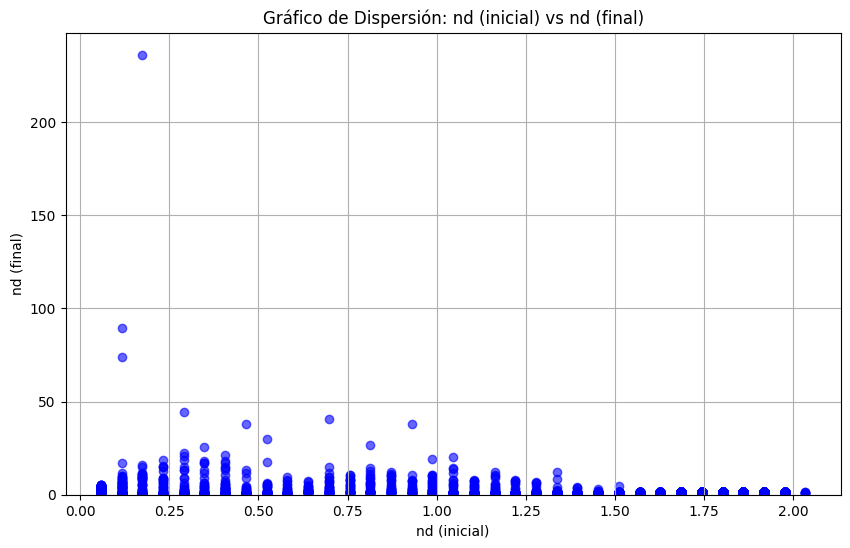

In [53]:
nd_0 = df['nd_0'] 
nd = df['nd']   

plt.figure(figsize=(10, 6))
plt.scatter(nd_0, nd, color='blue', alpha=0.6)
plt.title('Gráfico de Dispersión: nd (inicial) vs nd (final)')
plt.xlabel('nd (inicial)')
plt.ylabel('nd (final)')
plt.ylim(0, )
plt.grid()
plt.show()

In [54]:
# Filtrar las curvas donde 'nd' es mayor o igual a 30 o es NaN
filtro3 = df[(df['nd'] >= 2) | (df['nd'].isna())]

# Imprimir el número de curvas filtradas
count3 = filtro3.shape[0]
print("Número de curvas filtradas con nd >= 30 o Coeficiente de Pearson tipo NaN:", count3)

# Imprimir la estampa de tiempo asociada (columna File_Name)
#print("Estampas de tiempo asociadas a las curvas filtradas:")
#print(filtro3[['ID','File_Name']])


Número de curvas filtradas con nd >= 30 o Coeficiente de Pearson tipo NaN: 520


In [69]:
# Filtrar las curvas donde 'nd_0' es mayor o igual a 30 o es NaN
filtro4 = df[(df['nd_0'] <= 1.5) | (df['nd_0'].isna())]

# Imprimir el número de curvas filtradas
count4 = filtro4.shape[0]
print("Número de curvas filtradas con nd_0 <= 1.5 o tipo NaN:", count4)

Número de curvas filtradas con nd_0 <= 1.5 o tipo NaN: 1890


**¿Cómo se comporta el factor de Resistencia Serie (Rs)?**

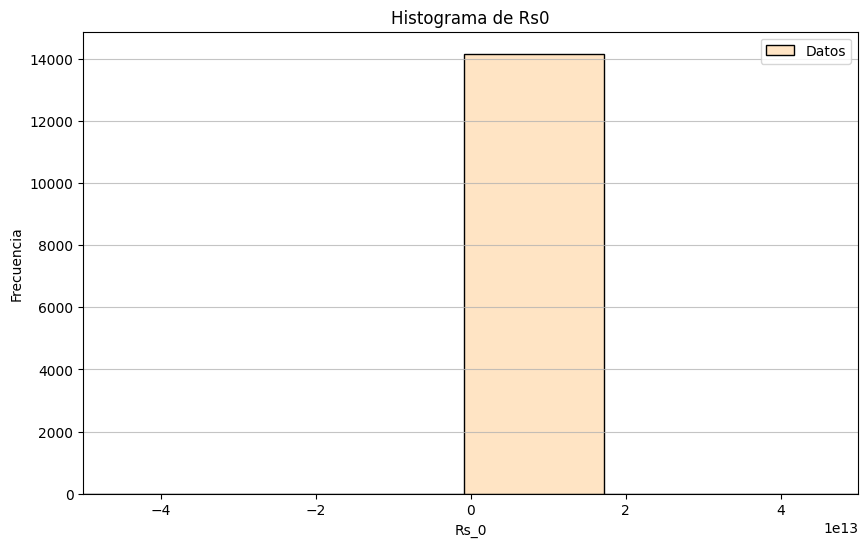

In [11]:
# Histograma del Rs_0
plt.figure(figsize=(10, 6))
plt.hist(df['Rs_0'], bins=20, color='bisque', edgecolor='black', label='Datos')
plt.title('Histograma de Rs0')
plt.xlabel('Rs_0')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.xlim(-0.5e14,0.5e14)
plt.legend()  
plt.show()

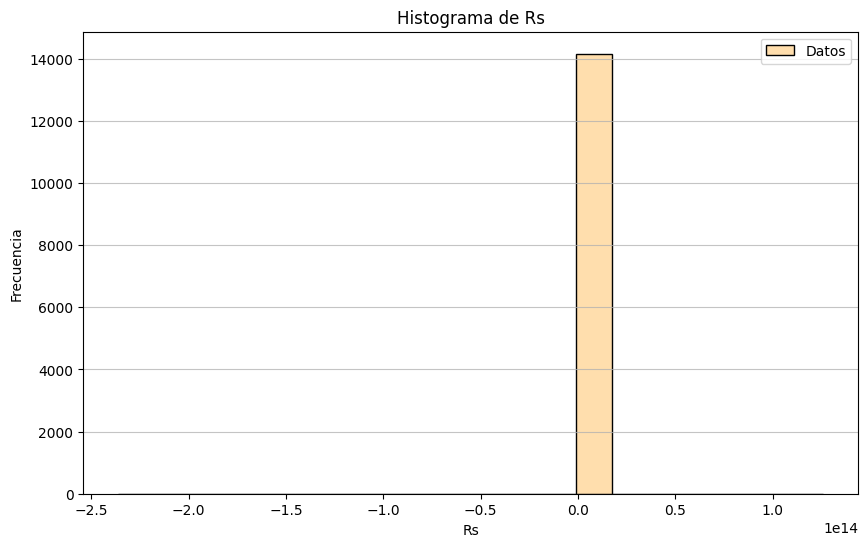

In [57]:
# Histograma del Rs
plt.figure(figsize=(10, 6))
plt.hist(df['Rs'], bins=20, color='navajowhite', edgecolor='black', label='Datos')
plt.title('Histograma de Rs')
plt.xlabel('Rs')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend()  
plt.show()

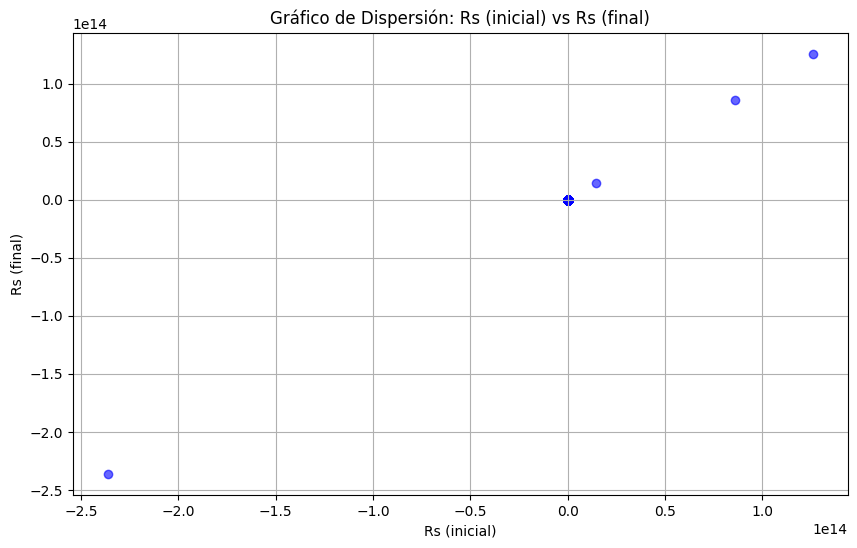

In [58]:
Rs_0 = df['Rs_0'] 
Rs = df['Rs']   

plt.figure(figsize=(10, 6))
plt.scatter(Rs_0, Rs, color='blue', alpha=0.6)
plt.title('Gráfico de Dispersión: Rs (inicial) vs Rs (final)')
plt.xlabel('Rs (inicial)')
plt.ylabel('Rs (final)')
#plt.ylim(0, )
plt.grid()
plt.show()

In [59]:
filtro5 = df[(df['Rs_0'] <= 0) | ((df['Rs_0'] > 0.1) & (df['Rs_0'] < 0.5))]

# Imprimir el número de curvas filtradas
count5 = filtro5.shape[0]
print("Número de curvas filtradas:", count5)

#print("Estampas de tiempo asociadas a las curvas filtradas:")
#print(filtro5[['ID','File_Name']])

Número de curvas filtradas: 595


**¿Cómo se comporta el factor de Resistencia Paralelo (Rp)?**

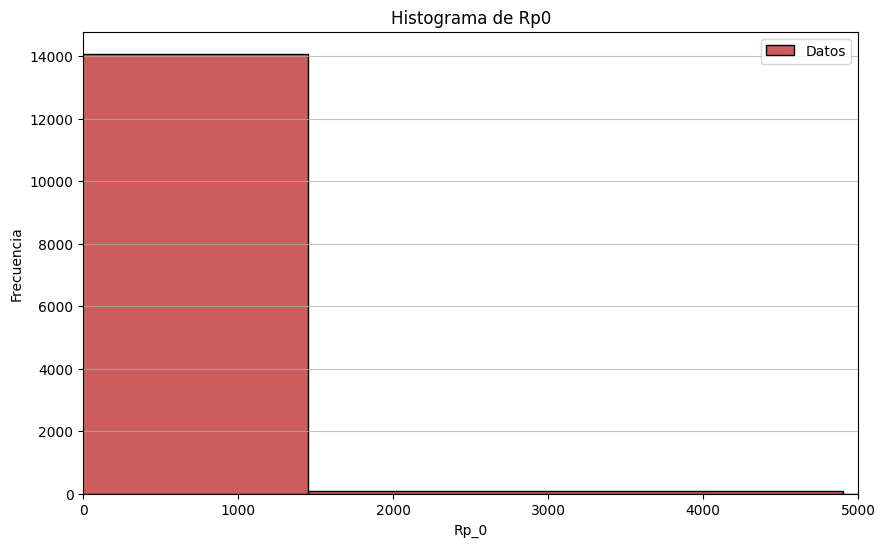

In [12]:
# Histograma del Rp_0
plt.figure(figsize=(10, 6))
plt.hist(df['Rp_0'], bins=20, color='indianred', edgecolor='black', label='Datos')
plt.title('Histograma de Rp0')
plt.xlabel('Rp_0')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.xlim(0,5000)
plt.legend()  
plt.show()

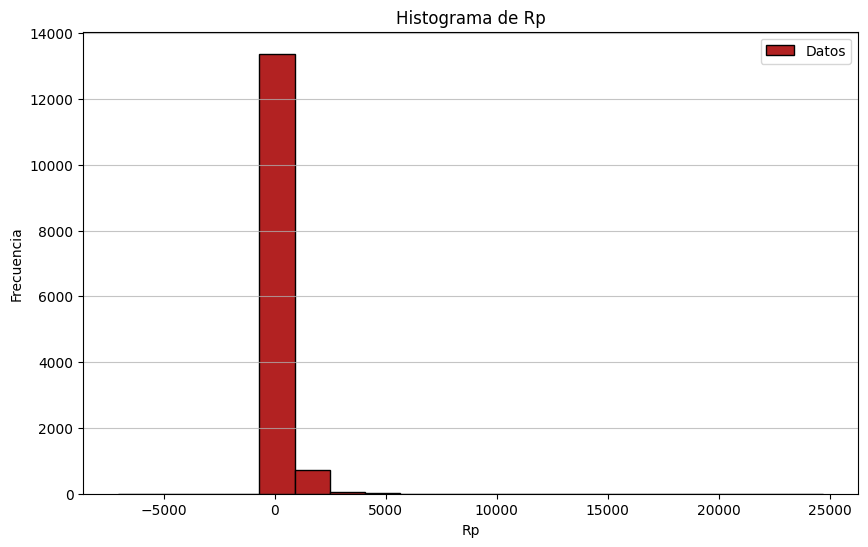

In [61]:
# Histograma del Rp
plt.figure(figsize=(10, 6))
plt.hist(df['Rp'], bins=20, color='firebrick', edgecolor='black', label='Datos')
plt.title('Histograma de Rp')
plt.xlabel('Rp')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
#plt.xlim(0,5000)
plt.legend()  
plt.show()

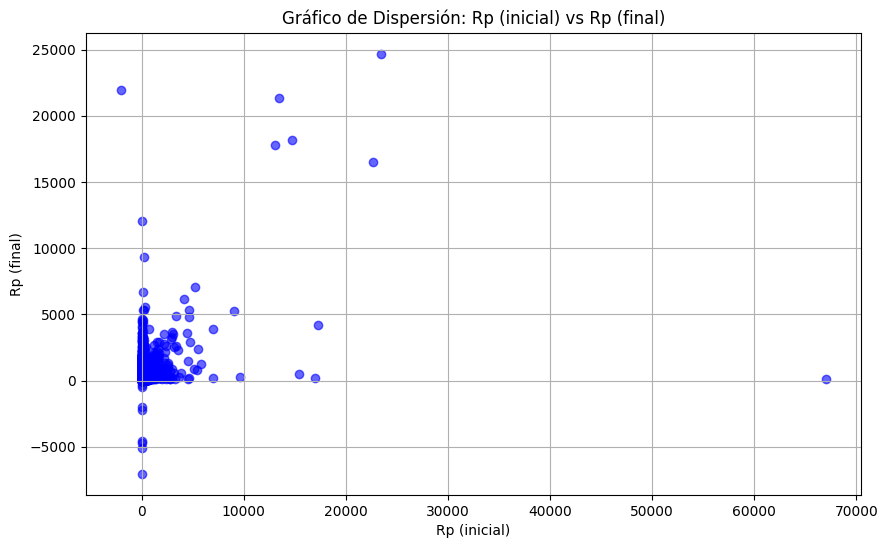

In [62]:
Rp_0 = df['Rp_0'] 
Rp = df['Rp']   

plt.figure(figsize=(10, 6))
plt.scatter(Rp_0, Rp, color='blue', alpha=0.6)
plt.title('Gráfico de Dispersión: Rp (inicial) vs Rp (final)')
plt.xlabel('Rp (inicial)')
plt.ylabel('Rp (final)')
#plt.ylim(0, )
plt.grid()
plt.show()

In [63]:
#filtro6 = df[(df['Rp_0'] >= 500) ]
filtro6 = df[(df['Rp_0'] <= 90)]

# Imprimir el número de curvas filtradas
count6 = filtro6.shape[0]
print("Número de curvas filtradas:", count6)

# Imprimir la estampa de tiempo asociada (columna File_Name)
#print("Estampas de tiempo asociadas a las curvas filtradas:")
#print(filtro6[['ID','File_Name']])
#print(df.head(10))

Número de curvas filtradas: 1346


In [64]:
# filtro7 = df[(df['Rp'] <= 0) ]
# #filtro6 = df[(df['Rs'] > 5)]

# # Imprimir el número de curvas filtradas
# count7 = filtro7.shape[0]
# print("Número de curvas filtradas:", count7)

# # Imprimir la estampa de tiempo asociada (columna File_Name)
# #print("Estampas de tiempo asociadas a las curvas filtradas:")
# #print(filtro6[['ID','File_Name']])
# #print(df.head(10))

**¿Cómo se comporta la corriente fotogenerada (Iph)?**

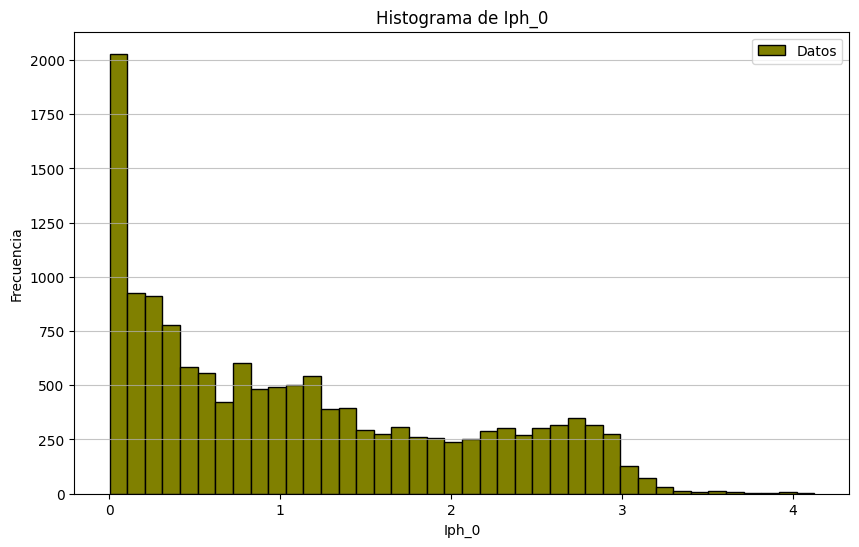

In [33]:
# Histograma de Iph_0
plt.figure(figsize=(10, 6))
plt.hist(df['Iph_0'], bins=40, color='olive', edgecolor='black', label='Datos')
plt.title('Histograma de Iph_0')
plt.xlabel('Iph_0')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend()  
plt.show()

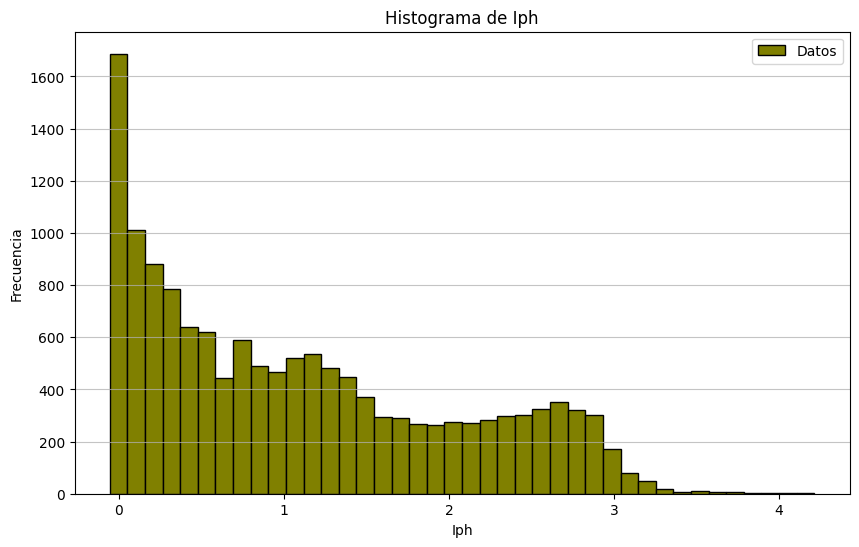

In [65]:
# Histograma de Iph
plt.figure(figsize=(10, 6))
plt.hist(df['Iph'], bins=40, color='olive', edgecolor='black', label='Datos')
plt.title('Histograma de Iph')
plt.xlabel('Iph')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend()  
plt.show()

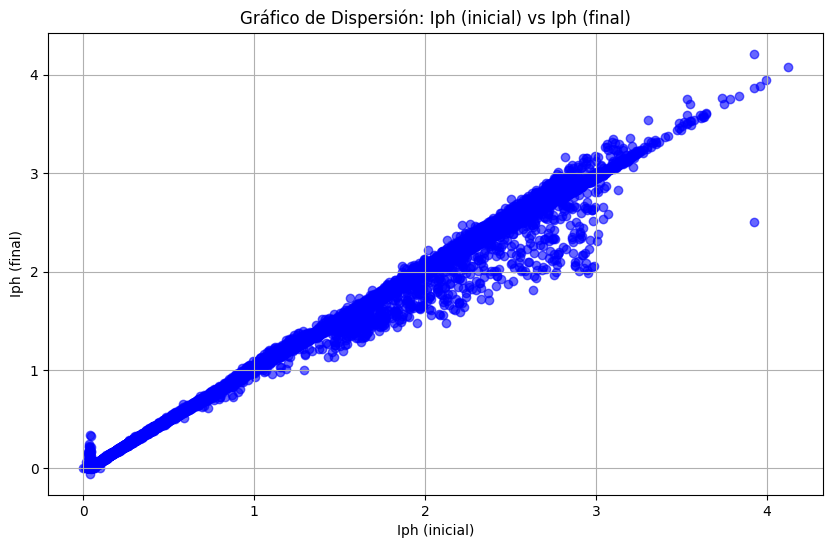

In [66]:
Iph_0 = df['Iph_0'] 
Iph = df['Iph']   

plt.figure(figsize=(10, 6))
plt.scatter(Iph_0, Iph, color='blue', alpha=0.6)
plt.title('Gráfico de Dispersión: Iph (inicial) vs Iph (final)')
plt.xlabel('Iph (inicial)')
plt.ylabel('Iph (final)')
#plt.ylim(0, )
plt.grid()
plt.show()

In [67]:
filtro8 = df[(df['Iph_0'] <= 0.06) ]

# Imprimir el número de curvas filtradas
count8 = filtro8.shape[0]
print("Número de curvas filtradas:", count8)

Número de curvas filtradas: 1315


In [70]:
#Filtro final
filtrof = df[((df['Coef_Pearson'] >= -0.2) | (df['Coef_Pearson'].isna())) | 
             ((df['Coef_Pearson'] <= -0.94)) |
             ((df['nd'] >= 2) | (df['nd'].isna())) |
             ((df['nd_0'] <= 1.5) | (df['nd_0'].isna())) |
             ((df['Rs_0'] <= 0) | ((df['Rs_0'] > 0.1) & (df['Rs_0'] < 0.5))) |
             ((df['Rp_0'] <= 90)) |
             (df['Iph_0'] <= 0.06) |
             (df['Is'] <= 1e-9) | (df['Is'] >= 0.05e-5) | (df['Is'].isna())
             ]

countf = filtrof.shape[0]
print("Número de curvas filtradas:", countf)

Número de curvas filtradas: 1930


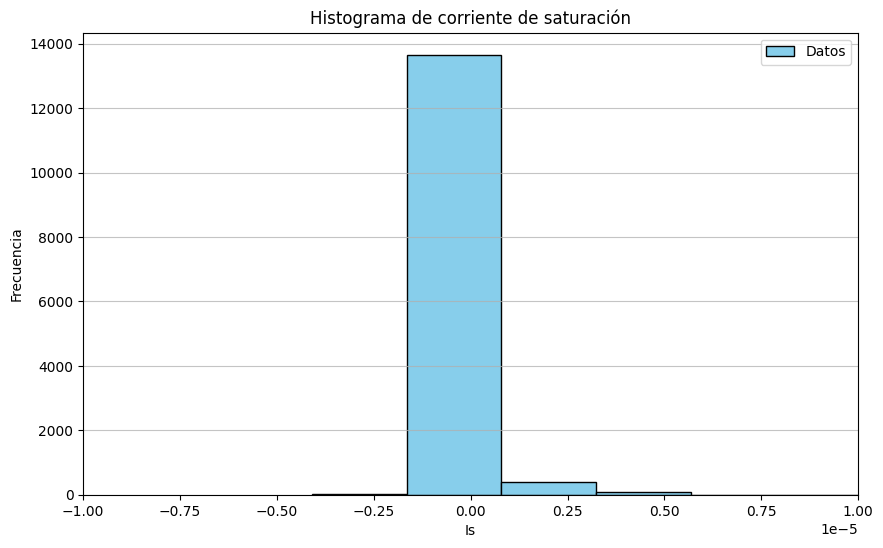

In [38]:
# Histograma del Coeficiente de Is
plt.figure(figsize=(10, 6))
plt.hist(df['Is'], bins=30, color='skyblue', edgecolor='black', label='Datos')
plt.title('Histograma de corriente de saturación')
plt.xlabel('Is')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.xlim(-1e-5, 1e-5)
plt.legend()  
plt.show()

In [39]:
# Filtrar corriente de saturación donde son NaN
filtro10 = df[(df['Is'] <= 1e-9) | (df['Is'] >= 0.05e-5) | (df['Is'].isna())]
count10 = filtro10.shape[0]
print("Número de curvas filtradas con corriente de saturación <= 1e-9 o >= 0.05e-5 o tipo NaN:", count10)

Número de curvas filtradas con corriente de saturación <= 1e-9 o >= 0.05e-5 o tipo NaN: 958


In [45]:
# Configurar la conexión a MariaDB
conexion = mysql.connector.connect(
    host="localhost",
    user="root",  # O el usuario que uses
    password="14123",
    port=3306,
    database="curvas_sync"
)

cursor = conexion.cursor()

ids_filtrados = filtro8['ID'].tolist()

# Recorrer los IDs filtrados
for id_value in ids_filtrados:
    query_iv = "SELECT curvaiv FROM curves_ajust_1 WHERE id = %s"
    cursor.execute(query_iv, (id_value,))
    
    # Obtener los resultados de la consulta
    resultado = cursor.fetchone()  
    
    if resultado:  # Asegurarse de que se ha obtenido un resultado
        data_str = resultado[0].strip('\'"')  
        data_dict = json.loads(data_str.replace("'", '"'))  

        voltaje = [float(v) for v in data_dict['Voltaje']]
        corriente = [float(c) for c in data_dict['Corriente']]
        
        Vmin_index = voltaje.index(min(voltaje))

        V_rango = voltaje[Vmin_index:]
        I_rango = corriente[Vmin_index:]

        # Graficar V_rango vs I_rango
        plt.plot(V_rango, I_rango, label=f'ID: {id_value}')
        plt.title(f'Gráfica de Voltaje vs Corriente (ID: {id_value})')
        plt.xlabel('Voltaje (V)')
        plt.ylabel('Corriente (I)')
        plt.grid()
        plt.legend()  # Mostrar leyenda con el ID
        
        # Especificar la ruta y nombre del archivo PNG
        ruta_guardado = f'/home/leider/Descargas/filtrado2/filtro8/grafica_id_{id_value}.png' 
        plt.savefig(ruta_guardado)  # Guardar la gráfica en un archivo
        plt.close('all')  # Cerrar la figura para liberar memoria

# Cerrar el cursor y la conexión
cursor.close()
conexion.close()


In [41]:
import mysql.connector
import json
import matplotlib.pyplot as plt

ids_filtrados = filtro3['ID'].tolist()

# Usar context manager para la conexión
with mysql.connector.connect(
    host="localhost",
    user="root",
    password="14123",
    port=3306,
    database="curvas_sync"
) as conexion:
    # Usar context manager para el cursor
    with conexion.cursor() as cursor:
        for id_value in ids_filtrados:
            query_iv = "SELECT curvaiv FROM curves_ajust_1 WHERE id = %s"
            cursor.execute(query_iv, (id_value,))
            
            # Obtener los resultados de la consulta
            resultado = cursor.fetchone()  
            
            if resultado:  # Asegurarse de que se ha obtenido un resultado
                data_str = resultado[0].strip('\'"')  
                data_dict = json.loads(data_str.replace("'", '"'))  

                voltaje = [float(v) for v in data_dict['Voltaje']]
                corriente = [float(c) for c in data_dict['Corriente']]
                
                Vmin_index = voltaje.index(min(voltaje))

                V_rango = voltaje[Vmin_index:]
                I_rango = corriente[Vmin_index:]

                # Crear y guardar la gráfica como antes
                fig, ax = plt.subplots()
                ax.plot(V_rango, I_rango, label=f'ID: {id_value}')
                ax.set_title(f'Gráfica de Voltaje vs Corriente (ID: {id_value})')
                ax.set_xlabel('Voltaje (V)')
                ax.set_ylabel('Corriente (I)')
                ax.grid()
                ax.legend()
                
                ruta_guardado = f'/home/leider/Descargas/filtrado2/filtro3/grafica_id_{id_value}.png'
                fig.savefig(ruta_guardado)
                plt.close(fig)
